In [1]:
#Library
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

## 1 Understanding data

In [2]:
df= pd.read_csv("../dataset/data.csv")
print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1])
df.head()
df

Jumlah data: 569
Jumlah fitur: 33


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())


Jumlah Missing Values per Kolom:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fract

In [5]:
print("\nJumlah duplikat Kolom:")
print(df.duplicated().sum())


Jumlah duplikat Kolom:
0


In [6]:
# hapus kolom yang tidak digunakan

if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)

if 'id' in df.columns:
    df = df.drop('id', axis=1)

print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1])

df.head()


Jumlah data: 569
Jumlah fitur: 31


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# counts of unique rows in the 'diagnosis' column
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [8]:
#Encoding Label
df['diagnosis'] = df['diagnosis'].map({
'M': 1,
'B': -1
})

df['diagnosis'].value_counts()

diagnosis
-1    357
 1    212
Name: count, dtype: int64

In [9]:
#Feature dan Label
X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values

print("Jumlah data :", len(X))
print("Jumlah fitur :", X.shape[1])

Jumlah data : 569
Jumlah fitur : 30


## 3. Split Data 70:30

In [10]:
def train_test_split_stratified(X, y, test_ratio=0.3, random_state=42):
    np.random.seed(random_state)

    classes = np.unique(y)
    train_idx = []
    test_idx = []

    for c in classes:
        # ambil index tiap kelas
        idx_c = np.where(y == c)[0]
        np.random.shuffle(idx_c)

        split = int(len(idx_c) * (1 - test_ratio))

        train_idx.extend(idx_c[:split])
        test_idx.extend(idx_c[split:])

    # acak ulang agar tidak berurutan per kelas
    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)

    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


# pakai fungsi
X_train, X_test, y_train, y_test = train_test_split_stratified(X, y)

print("Jumlah data total :", len(X))
print("Jumlah data train :", len(X_train))
print("Jumlah data test  :", len(X_test))

Jumlah data total : 569
Jumlah data train : 397
Jumlah data test  : 172


In [11]:
def check_distribution(y, name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\nDistribusi {name}:")
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c} ({round(c/len(y)*100,2)}%)")

check_distribution(y_train, "Train")
check_distribution(y_test, "Test")


Distribusi Train:
Class -1: 249 (62.72%)
Class 1: 148 (37.28%)

Distribusi Test:
Class -1: 108 (62.79%)
Class 1: 64 (37.21%)


## 4. Normalisasi

In [12]:
# MIN-MAX FIT
def minmax_fit(X):
    # pastikan tipe float
    X = X.astype(float)
    
    # hitung min dan max tiap fitur
    min_vals = np.min(X, axis=0)
    max_vals = np.max(X, axis=0)

    return min_vals, max_vals


# MIN-MAX TRANSFORM 
def minmax_transform(X, min_vals, max_vals):
    X = X.astype(float)
    
    # hindari pembagian nol
    denominator = max_vals - min_vals
    denominator[denominator == 0] = 1e-8

    X_norm = (X - min_vals) / denominator

    return X_norm


# FIT (HANYA DATA TRAIN)
min_vals, max_vals = minmax_fit(X_train)


#  TRANSFORM 
X_train = minmax_transform(X_train, min_vals, max_vals)
X_test = minmax_transform(X_test, min_vals, max_vals)


# CEK HASIL 
print("=== HASIL NORMALISASI ===")

print("\nTrain:")
print("Min (global):", np.min(X_train))
print("Max (global):", np.max(X_train))

print("\nTest:")
print("Min (global):", np.min(X_test))
print("Max (global):", np.max(X_test))


# CEK PER FITUR 
print("\n=== CEK PER FITUR (TRAIN) ===")
print("Min per fitur:", np.min(X_train, axis=0))
print("Max per fitur:", np.max(X_train, axis=0))

=== HASIL NORMALISASI ===

Train:
Min (global): 0.0
Max (global): 1.0

Test:
Min (global): -0.0979284369114877
Max (global): 1.2784498982217614

=== CEK PER FITUR (TRAIN) ===
Min per fitur: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Max per fitur: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


## 5.Fitur Selection

In [13]:
# =========================================
# FEATURE SELECTION (FISHER SCORE)
# =========================================

def fisher_score(X, y):
    classes = np.unique(y)
    scores_fs = []
    for i in range(X.shape[1]):
        overall_mean = np.mean(X[:, i])
        numerator = 0
        denominator = 0
        for c in classes:
            X_c = X[y == c, i]
            if len(X_c) == 0:
                continue
            mean_c = np.mean(X_c)
            var_c = np.var(X_c)
            numerator += (
                len(X_c) *
                (mean_c - overall_mean) ** 2
            )
            denominator += (
                len(X_c) * var_c
            )
        score = numerator / (denominator + 1e-8)
        scores_fs.append(score)
    return np.array(scores_fs)

# HITUNG SCORE
scores_fs = fisher_score(
    X_train,
    y_train
)

# RANKING FITUR
idx_fs = np.argsort(scores_fs)[::-1]
top_k_fs = 10
selected_idx_fs = idx_fs[:top_k_fs]

print(
    "Selected feature indices:",
    selected_idx_fs
)

# APPLY FEATURE SELECTION
X_train_fs = X_train[:, selected_idx_fs]

X_test_fs = X_test[:, selected_idx_fs]

print("Shape asli:", X_train.shape)

print("Shape FS :", X_train_fs.shape)

Selected feature indices: [22 27 20  7 23  2  0  3  6 26]
Shape asli: (397, 30)
Shape FS : (397, 10)


Top 10 Selected feature indices: [22 27 20  7 23  2  0  3  6 26]
                    Feature     Score
22          perimeter_worst  1.567175
27     concave points_worst  1.558130
20             radius_worst  1.504207
7       concave points_mean  1.442318
23               area_worst  1.189410
2            perimeter_mean  1.180886
0               radius_mean  1.095762
3                 area_mean  0.980034
6            concavity_mean  0.792834
26          concavity_worst  0.644144
5          compactness_mean  0.533870
25        compactness_worst  0.478997
10                radius_se  0.478647
13                  area_se  0.474208
12             perimeter_se  0.445573
21            texture_worst  0.251509
24         smoothness_worst  0.237250
28           symmetry_worst  0.211962
1              texture_mean  0.173867
4           smoothness_mean  0.173725
17        concave points_se  0.170062
8             symmetry_mean  0.113136
29  fractal_dimension_worst  0.095298
15           compactnes

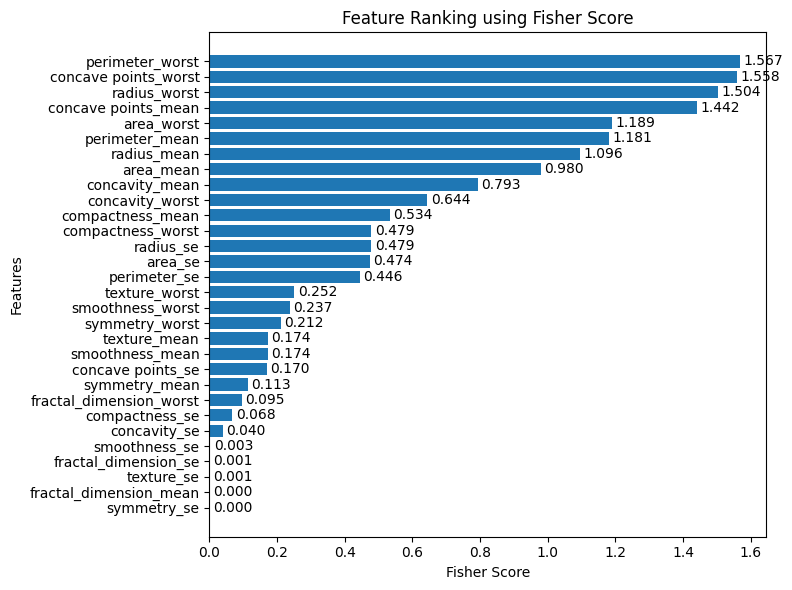

In [14]:
feature_names = df.drop(columns=['diagnosis']).columns

ranking_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores_fs
})

ranking_df = ranking_df.sort_values(by='Score', ascending=False)
print("Top 10 Selected feature indices:", selected_idx_fs)
print(ranking_df)


plt.figure(figsize=(8, 6))
bars = plt.barh(ranking_df['Feature'], ranking_df['Score'])
plt.xlabel('Fisher Score')
plt.ylabel('Features')
plt.title('Feature Ranking using Fisher Score')
plt.gca().invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}',
            va='center')

plt.tight_layout()
plt.show()

In [15]:
# =========================================
# EVALUATION METRICS
# =========================================

def evaluate_model(y_true, y_pred):

    tp_eval = np.sum((y_pred == 1) & (y_true == 1))
    tn_eval = np.sum((y_pred == -1) & (y_true == -1))
    fp_eval = np.sum((y_pred == 1) & (y_true == -1))
    fn_eval = np.sum((y_pred == -1) & (y_true == 1))

    accuracy_eval = (tp_eval + tn_eval) / (tp_eval + tn_eval + fp_eval + fn_eval + 1e-8)

    precision_eval = tp_eval / (tp_eval + fp_eval + 1e-8)

    recall_eval = tp_eval / (tp_eval + fn_eval + 1e-8)

    f1_eval = 2 * (precision_eval * recall_eval) / (precision_eval + recall_eval + 1e-8)

    return accuracy_eval, precision_eval, recall_eval, f1_eval, tp_eval, tn_eval, fp_eval, fn_eval

## 6. Model SVM

In [16]:
# =========================================
# SVM PREDICTION
# =========================================

def svm_predict(X, w, b):

    linear_pred = np.dot(X, w) + b

    predictions_svm = np.sign(linear_pred)

    # jika 0 → jadikan 1
    predictions_svm[predictions_svm == 0] = 1

    return predictions_svm

In [17]:
# =========================================
# SVM TRAINING
# =========================================

def svm_train(X, y,
              lr=0.001,
              C=0.1,
              lambda_param=0.001,
              epochs=500,
              early_stop=True,
              tolerance=1e-6):

    n_samples_svm, n_features_svm = X.shape
    # label menjadi -1 dan 1
    y_svm = np.where(y <= 0, -1, 1)
    # inisialisasi parameter
    w_svm = np.zeros(n_features_svm)
    b_svm = 0.0

    losses_svm = []

    print("===== TRAINING SVM =====")

    for epoch_svm in range(epochs):

        # shuffle data
        indices_svm = np.arange(n_samples_svm)
        np.random.shuffle(indices_svm)

        total_loss_svm = 0

        for i_svm in indices_svm:

            x_i_svm = X[i_svm]
            y_i_svm = y_svm[i_svm]

            # hitung margin
            margin_svm = y_i_svm * (np.dot(x_i_svm, w_svm) + b_svm)

            # hinge loss
            hinge_loss_svm = max(0, 1 - margin_svm)

            # total loss
            total_loss_svm += hinge_loss_svm + lambda_param * np.sum(w_svm ** 2)

            # gradient descent
            if margin_svm >= 1:

                dw_svm = 2 * lambda_param * w_svm
                db_svm = 0

            else:

                dw_svm = 2 * lambda_param * w_svm - C * y_i_svm * x_i_svm
                db_svm = -C * y_i_svm

            # update parameter
            w_svm -= lr * dw_svm
            b_svm -= lr * db_svm

            # clipping
            w_svm = np.clip(w_svm, -10, 10)

        # rata-rata loss
        avg_loss_svm = total_loss_svm / n_samples_svm

        losses_svm.append(avg_loss_svm)

        # print loss
        if (epoch_svm + 1) % 10 == 0 or epoch_svm == 0:

            print(f"Epoch {epoch_svm+1}/{epochs} | Loss: {avg_loss_svm:.6f}")

        # early stopping
        if early_stop and epoch_svm > 5:

            improvement_svm = abs(losses_svm[-1] - losses_svm[-2])

            if improvement_svm < tolerance:

                print(f"Early stopping at epoch {epoch_svm+1}")

                break

    return w_svm, b_svm, losses_svm

In [18]:
# CONFUSION MATRIX
def plot_confusion_matrix(tp, tn, fp, fn, title="Confusion Matrix"):

    cm_matrix = np.array([[tp, fn], [fp, tn]])
    labels_cm = [["TP", "FN"], ["FP", "TN"]]

    plt.figure(figsize=(5,5))
    plt.imshow(cm_matrix, cmap='Blues')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i_cm in range(2):
        for j_cm in range(2):

            plt.text(j_cm, i_cm,
                     f"{labels_cm[i_cm][j_cm]}\n{cm_matrix[i_cm,j_cm]}",
                     ha='center', va='center', color='black')

    plt.colorbar()
    plt.show()

### 6.1 Model SVM Tanpa FS

===== TRAINING SVM =====
Epoch 1/500 | Loss: 0.997709
Epoch 10/500 | Loss: 0.953213
Epoch 20/500 | Loss: 0.903970
Epoch 30/500 | Loss: 0.854929
Epoch 40/500 | Loss: 0.806092
Epoch 50/500 | Loss: 0.757457
Epoch 60/500 | Loss: 0.709019
Epoch 70/500 | Loss: 0.662489
Epoch 80/500 | Loss: 0.622974
Epoch 90/500 | Loss: 0.590820
Epoch 100/500 | Loss: 0.561583
Epoch 110/500 | Loss: 0.534073
Epoch 120/500 | Loss: 0.509179
Epoch 130/500 | Loss: 0.486227
Epoch 140/500 | Loss: 0.465622
Epoch 150/500 | Loss: 0.447008
Epoch 160/500 | Loss: 0.430111
Epoch 170/500 | Loss: 0.415091
Epoch 180/500 | Loss: 0.401527
Epoch 190/500 | Loss: 0.389242
Epoch 200/500 | Loss: 0.377827
Epoch 210/500 | Loss: 0.367624
Epoch 220/500 | Loss: 0.358281
Epoch 230/500 | Loss: 0.349842
Epoch 240/500 | Loss: 0.342105
Epoch 250/500 | Loss: 0.335004
Epoch 260/500 | Loss: 0.328614
Epoch 270/500 | Loss: 0.322906
Epoch 280/500 | Loss: 0.317801
Epoch 290/500 | Loss: 0.313236
Epoch 300/500 | Loss: 0.308908
Epoch 310/500 | Loss: 0.3

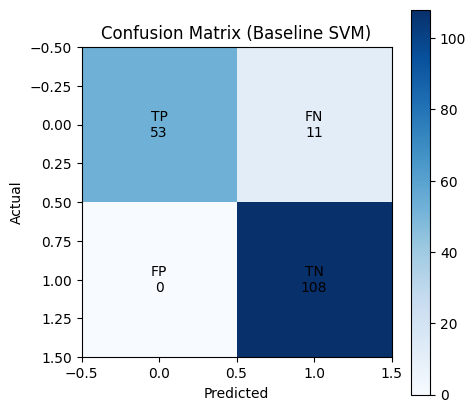

AUC Score: 0.9986


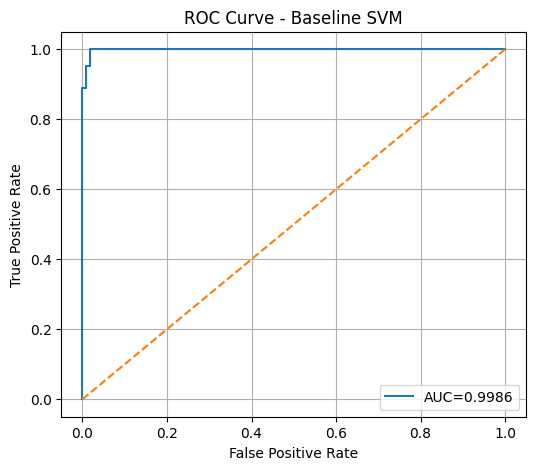

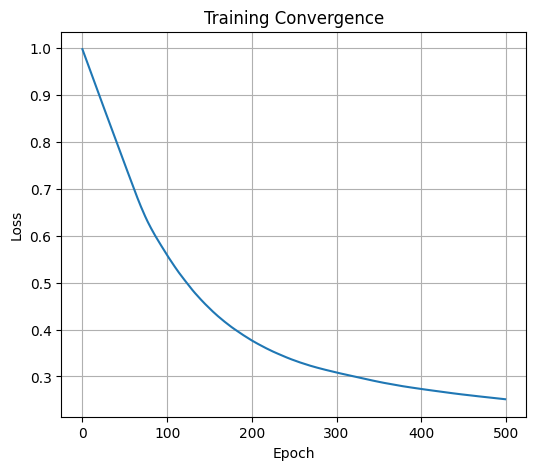

In [19]:
# DECISION FUNCTION
def svm_decision_function(X, w, b):
    return np.dot(X, w) + b

# TRAIN
w_base3, b_base3, losses_base3 = svm_train(
    X_train, y_train, lr=0.001,
    C=0.1, lambda_param=0.001,
    epochs=500
)

# PREDIKSI & EVALUASI
y_pred_base3 = svm_predict(X_test, w_base3, b_base3)

acc_base3, pre_base3, rec_base3, f1_base3, tp_base3, tn_base3, fp_base3, fn_base3 = evaluate_model(
    y_test, y_pred_base3
)

# HASIL
print("\n===== BASELINE SVM =====")
print(f"Accuracy : {acc_base3*100:.2f}%")
print(f"Precision: {pre_base3*100:.2f}%")
print(f"Recall   : {rec_base3*100:.2f}%")
print(f"F1 Score : {f1_base3*100:.2f}%")
print(f"TP:{tp_base3}, TN:{tn_base3}, FP:{fp_base3}, FN:{fn_base3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_base3, tn_base3,
    fp_base3, fn_base3,
    title="Confusion Matrix (Baseline SVM)"
)

# ROC-AUC
scores_base3 = svm_decision_function(X_test, w_base3, b_base3)

auc_base3 = roc_auc_score(y_test, scores_base3)

print(f"AUC Score: {auc_base3:.4f}")

fpr_base3, tpr_base3, _ = roc_curve(y_test, scores_base3)

plt.figure(figsize=(6,5))
plt.plot(fpr_base3, tpr_base3, label=f"AUC={auc_base3:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - Baseline SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()
plt.show()

# LOSS CURVE
plt.figure(figsize=(6,5))
plt.plot(losses_base3)
plt.title("Training Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

### 6.2 Model SVM + FS

===== TRAINING SVM =====
Epoch 1/500 | Loss: 0.998112
Epoch 10/500 | Loss: 0.962223
Epoch 20/500 | Loss: 0.922462
Epoch 30/500 | Loss: 0.882824
Epoch 40/500 | Loss: 0.843306
Epoch 50/500 | Loss: 0.803911
Epoch 60/500 | Loss: 0.764631
Epoch 70/500 | Loss: 0.725477
Epoch 80/500 | Loss: 0.686426
Epoch 90/500 | Loss: 0.647502
Epoch 100/500 | Loss: 0.608724
Epoch 110/500 | Loss: 0.571327
Epoch 120/500 | Loss: 0.538295
Epoch 130/500 | Loss: 0.510310
Epoch 140/500 | Loss: 0.487736
Epoch 150/500 | Loss: 0.468078
Epoch 160/500 | Loss: 0.451011
Epoch 170/500 | Loss: 0.435518
Epoch 180/500 | Loss: 0.421278
Epoch 190/500 | Loss: 0.407930
Epoch 200/500 | Loss: 0.395642
Epoch 210/500 | Loss: 0.384681
Epoch 220/500 | Loss: 0.374453
Epoch 230/500 | Loss: 0.364634
Epoch 240/500 | Loss: 0.355772
Epoch 250/500 | Loss: 0.347824
Epoch 260/500 | Loss: 0.340777
Epoch 270/500 | Loss: 0.334477
Epoch 280/500 | Loss: 0.329297
Epoch 290/500 | Loss: 0.324667
Epoch 300/500 | Loss: 0.320410
Epoch 310/500 | Loss: 0.3

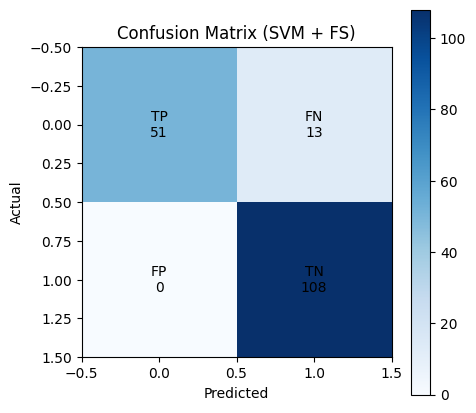

AUC Score: 0.9968


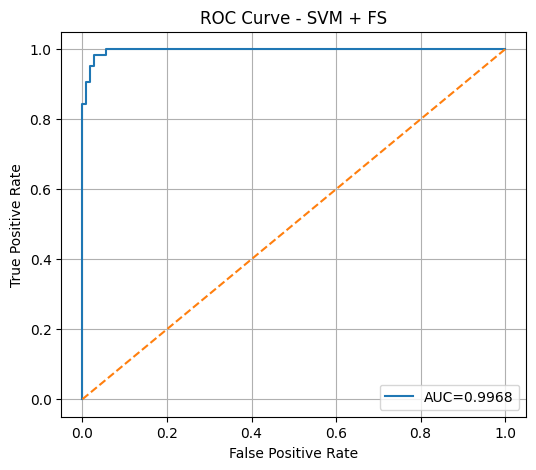

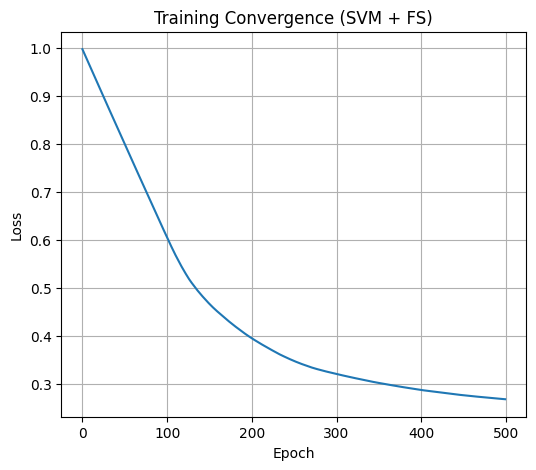

In [20]:
# TRAIN (SVM + FS)
w_fs3, b_fs3, losses_fs3 = svm_train(
    X_train_fs, y_train,
    lr=0.001, C=0.1,
    lambda_param=0.001,
    epochs=500
)

# PREDIKSI & EVALUASI
y_pred_fs3 = svm_predict(X_test_fs, w_fs3, b_fs3)

acc_fs3, pre_fs3, rec_fs3, f1_fs3, tp_fs3, tn_fs3, fp_fs3, fn_fs3 = evaluate_model(
    y_test, y_pred_fs3
)

# HASIL
print("\n===== SVM + FEATURE SELECTION =====")
print(f"Accuracy : {acc_fs3*100:.2f}%")
print(f"Precision: {pre_fs3*100:.2f}%")
print(f"Recall   : {rec_fs3*100:.2f}%")
print(f"F1 Score : {f1_fs3*100:.2f}%")
print(f"TP:{tp_fs3}, TN:{tn_fs3}, FP:{fp_fs3}, FN:{fn_fs3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_fs3, tn_fs3,
    fp_fs3, fn_fs3,
    title="Confusion Matrix (SVM + FS)"
)

# ROC-AUC
scores_fs3 = svm_decision_function(X_test_fs, w_fs3, b_fs3)

auc_fs3 = roc_auc_score(y_test, scores_fs3)

print(f"AUC Score: {auc_fs3:.4f}")

fpr_fs3, tpr_fs3, _ = roc_curve(y_test, scores_fs3)

plt.figure(figsize=(6,5))
plt.plot(fpr_fs3, tpr_fs3, label=f"AUC={auc_fs3:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - SVM + FS")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()
plt.show()

# LOSS CURVE
plt.figure(figsize=(6,5))
plt.plot(losses_fs3)
plt.title("Training Convergence (SVM + FS)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 7. Optimasi Parameter SVM dengan Firefly Algorithm (FA)

### 7.1 Model FA

In [21]:
# FITNESS FUNCTION (K-FOLD)

def svm_fitness_kfold(X, y, lr,
                      lambda_param,
                      C, k=5):

    scores_fa = []

    for X_tr_fa, X_val_fa, y_tr_fa, y_val_fa in kfold_split_stratified(X, y, k):

        try:

            w_fa, b_fa, _ = svm_train(
                X_tr_fa, y_tr_fa,
                lr=lr, C=C,
                lambda_param=lambda_param,
                epochs=100,
                early_stop=True
            )

            y_pred_fa = svm_predict(
                X_val_fa,
                w_fa,
                b_fa
            )

            _, _, _, f1_fa, *_ = evaluate_model(
                y_val_fa,
                y_pred_fa
            )

            if np.isnan(f1_fa) or np.isinf(f1_fa):
                f1_fa = 0

            scores_fa.append(f1_fa)

        except Exception:

            scores_fa.append(0)

    return np.mean(scores_fa)

In [22]:
# STRATIFIED K-FOLD

def kfold_split_stratified(X, y, k=5):

    classes_kf = np.unique(y)

    folds_kf = [[] for _ in range(k)]

    for c_kf in classes_kf:

        idx_c_kf = np.where(y == c_kf)[0]

        np.random.shuffle(idx_c_kf)

        split_kf = np.array_split(idx_c_kf, k)

        for i_kf in range(k):

            folds_kf[i_kf].extend(split_kf[i_kf])

    for i_kf in range(k):

        val_idx_kf = np.array(folds_kf[i_kf])

        train_idx_kf = np.hstack([
            folds_kf[j_kf]
            for j_kf in range(k)
            if j_kf != i_kf
        ])

        yield (
            X[train_idx_kf],
            X[val_idx_kf],
            y[train_idx_kf],
            y[val_idx_kf]
        )

In [23]:
# FIREFLY ALGORITHM

def firefly_algorithm(X, y,
                    n_fireflies=15,
                    max_iter=15,
                    alpha=0.2,
                    beta0=1,
                    gamma=1):

    lr_range_fa = [0.0001, 0.001]
    lambda_range_fa = [0.0001, 0.01]
    C_range_fa = [0.1, 50]

    fireflies_fa = np.random.rand(n_fireflies, 3)

    fireflies_fa[:,0] = fireflies_fa[:,0] * (lr_range_fa[1]-lr_range_fa[0]) + lr_range_fa[0]
    fireflies_fa[:,1] = fireflies_fa[:,1] * (lambda_range_fa[1]-lambda_range_fa[0]) + lambda_range_fa[0]
    fireflies_fa[:,2] = fireflies_fa[:,2] * (C_range_fa[1]-C_range_fa[0]) + C_range_fa[0]

    fitness_fa = np.zeros(n_fireflies)

    history_fa = []

    print("===== INITIAL FITNESS =====")

    for i_fa in range(n_fireflies):

        lr_fa, lam_fa, C_fa = fireflies_fa[i_fa]

        fitness_fa[i_fa] = svm_fitness_kfold(
            X, y, lr_fa, lam_fa, C_fa
        )

        print(f"Firefly {i_fa+1}: {fitness_fa[i_fa]:.4f}")

    best_idx_fa = np.argmax(fitness_fa)

    global_best_fa = fireflies_fa[best_idx_fa].copy()

    global_best_fitness_fa = fitness_fa[best_idx_fa]

    for t_fa in range(max_iter):

        print(f"\n===== Iteration {t_fa+1} =====")

        for i_fa in range(n_fireflies):

            for j_fa in range(n_fireflies):

                if fitness_fa[j_fa] > fitness_fa[i_fa]:

                    r_fa = np.linalg.norm(
                        fireflies_fa[i_fa] - fireflies_fa[j_fa]
                    )

                    beta_fa = beta0 * np.exp(-gamma * r_fa**2)

                    step_fa = alpha * (np.random.rand(3) - 0.5)

                    new_firefly_fa = (
                        fireflies_fa[i_fa]
                        + beta_fa * (fireflies_fa[j_fa] - fireflies_fa[i_fa])
                        + step_fa
                    )

                    new_firefly_fa[0] = np.clip(new_firefly_fa[0], *lr_range_fa)
                    new_firefly_fa[1] = np.clip(new_firefly_fa[1], *lambda_range_fa)
                    new_firefly_fa[2] = np.clip(new_firefly_fa[2], *C_range_fa)

                    lr_fa, lam_fa, C_fa = new_firefly_fa

                    new_fitness_fa = svm_fitness_kfold(
                        X, y, lr_fa, lam_fa, C_fa
                    )

                    if new_fitness_fa > fitness_fa[i_fa]:

                        fireflies_fa[i_fa] = new_firefly_fa

                        fitness_fa[i_fa] = new_fitness_fa

        best_idx_fa = np.argmax(fitness_fa)

        if fitness_fa[best_idx_fa] > global_best_fitness_fa:

            global_best_fitness_fa = fitness_fa[best_idx_fa]

            global_best_fa = fireflies_fa[best_idx_fa].copy()

        history_fa.append(global_best_fitness_fa)

        print(f"Best Fitness: {global_best_fitness_fa:.4f}")

        alpha *= 0.95

    return global_best_fa, history_fa

### 7.2 Model SVM + FA

In [24]:
# FIREFLY OPTIMIZATION

best_params_fa3, history_fa3 = firefly_algorithm(
    X_train,
    y_train
)

best_lr_fa3, best_lambda_fa3, best_C_fa3 = best_params_fa3

print("\n===== PARAMETER TERBAIK FA =====")

print(f"Best LR     : {best_lr_fa3:.6f}")
print(f"Best Lambda : {best_lambda_fa3:.6f}")
print(f"Best C      : {best_C_fa3:.6f}")

===== INITIAL FITNESS =====
===== TRAINING SVM =====
Epoch 1/100 | Loss: 0.922935
Epoch 10/100 | Loss: 0.296157
Epoch 20/100 | Loss: 0.226758
Epoch 30/100 | Loss: 0.208506
Epoch 40/100 | Loss: 0.198798
Epoch 50/100 | Loss: 0.192900
Epoch 60/100 | Loss: 0.188966
Epoch 70/100 | Loss: 0.186309
Epoch 80/100 | Loss: 0.184481
Epoch 90/100 | Loss: 0.183844
Epoch 100/100 | Loss: 0.183048
===== TRAINING SVM =====
Epoch 1/100 | Loss: 0.917218
Epoch 10/100 | Loss: 0.283443
Epoch 20/100 | Loss: 0.220983
Epoch 30/100 | Loss: 0.203820
Epoch 40/100 | Loss: 0.193255
Epoch 50/100 | Loss: 0.187212
Epoch 60/100 | Loss: 0.181974
Epoch 70/100 | Loss: 0.177558
Epoch 80/100 | Loss: 0.175102
Epoch 90/100 | Loss: 0.172530
Epoch 100/100 | Loss: 0.172059
===== TRAINING SVM =====
Epoch 1/100 | Loss: 0.912571
Epoch 10/100 | Loss: 0.273480
Epoch 20/100 | Loss: 0.211926
Epoch 30/100 | Loss: 0.193432
Epoch 40/100 | Loss: 0.185203
Early stopping at epoch 43
===== TRAINING SVM =====
Epoch 1/100 | Loss: 0.918713
Epoch 1

In [25]:
# TRAIN SVM + FA

w_fa3, b_fa3, losses_fa3 = svm_train(
    X_train,
    y_train,
    lr=best_lr_fa3,
    C=best_C_fa3,
    lambda_param=best_lambda_fa3,
    epochs=500,
    early_stop=True
)

===== TRAINING SVM =====
Epoch 1/500 | Loss: 0.467754
Epoch 10/500 | Loss: 0.118053
Epoch 20/500 | Loss: 0.096639
Epoch 30/500 | Loss: 0.087277
Epoch 40/500 | Loss: 0.082432
Epoch 50/500 | Loss: 0.079776
Epoch 60/500 | Loss: 0.074775
Epoch 70/500 | Loss: 0.072152
Epoch 80/500 | Loss: 0.072207
Epoch 90/500 | Loss: 0.074048
Epoch 100/500 | Loss: 0.070933
Epoch 110/500 | Loss: 0.073603
Epoch 120/500 | Loss: 0.071304
Epoch 130/500 | Loss: 0.070613
Epoch 140/500 | Loss: 0.070828
Epoch 150/500 | Loss: 0.072065
Epoch 160/500 | Loss: 0.072471
Epoch 170/500 | Loss: 0.072602
Epoch 180/500 | Loss: 0.072471
Epoch 190/500 | Loss: 0.071438
Epoch 200/500 | Loss: 0.073902
Epoch 210/500 | Loss: 0.071754
Epoch 220/500 | Loss: 0.072248
Epoch 230/500 | Loss: 0.073141
Epoch 240/500 | Loss: 0.071370
Epoch 250/500 | Loss: 0.073068
Epoch 260/500 | Loss: 0.070724
Epoch 270/500 | Loss: 0.072727
Epoch 280/500 | Loss: 0.074545
Epoch 290/500 | Loss: 0.073968
Epoch 300/500 | Loss: 0.072361
Epoch 310/500 | Loss: 0.0


===== SVM + FA (NO FS) =====
Accuracy : 97.09%
Precision: 98.36%
Recall   : 93.75%
F1 Score : 96.00%
TP:60, TN:107, FP:1, FN:4


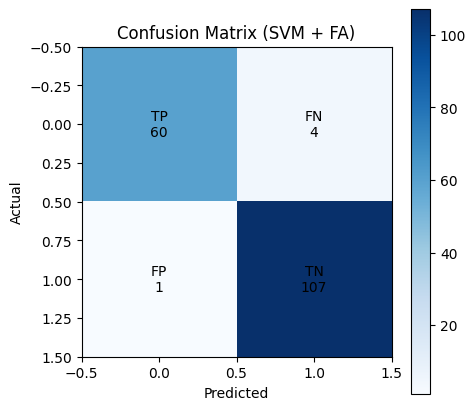

In [26]:
# PREDIKSI & EVALUASI (SVM + FA)

y_pred_fa3 = svm_predict(X_test, w_fa3, b_fa3)

acc_fa3, pre_fa3, rec_fa3, f1_fa3, tp_fa3, tn_fa3, fp_fa3, fn_fa3 = evaluate_model(
    y_test,
    y_pred_fa3
)

print("\n===== SVM + FA (NO FS) =====")
print(f"Accuracy : {acc_fa3*100:.2f}%")
print(f"Precision: {pre_fa3*100:.2f}%")
print(f"Recall   : {rec_fa3*100:.2f}%")
print(f"F1 Score : {f1_fa3*100:.2f}%")
print(f"TP:{tp_fa3}, TN:{tn_fa3}, FP:{fp_fa3}, FN:{fn_fa3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_fa3, tn_fa3,
    fp_fa3, fn_fa3,
    title="Confusion Matrix (SVM + FA)"
)

AUC Score (SVM + FA): 0.9955


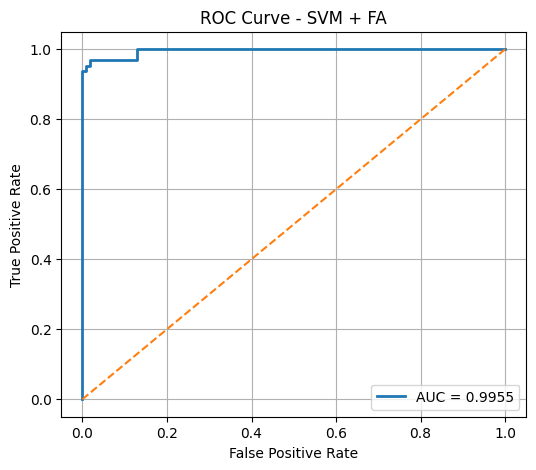

In [27]:
# ROC-AUC (SVM + FA)

scores_fa3 = svm_decision_function(X_test, w_fa3, b_fa3)

auc_fa3 = roc_auc_score(y_test, scores_fa3)

print(f"AUC Score (SVM + FA): {auc_fa3:.4f}")

fpr_fa3, tpr_fa3, _ = roc_curve(y_test, scores_fa3)

plt.figure(figsize=(6,5))

plt.plot(fpr_fa3, tpr_fa3, linewidth=2,
        label=f"AUC = {auc_fa3:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve - SVM + FA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.show()

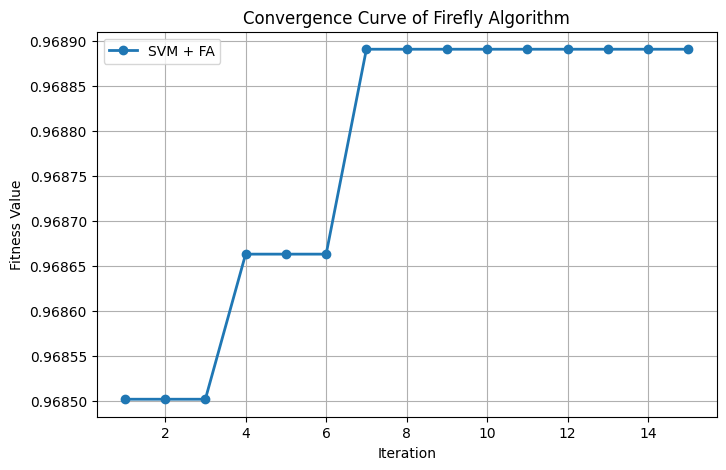

In [28]:
# CONVERGENCE CURVE

plt.figure(figsize=(8,5))

plt.plot(range(1, len(history_fa3)+1),
        history_fa3,
        marker='o',
        linewidth=2,
        label='SVM + FA')

plt.title("Convergence Curve of Firefly Algorithm")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")

plt.legend()
plt.grid(True)

plt.show()

### 7.3 Model SVM + FA + FS

In [29]:
# FIREFLY OPTIMIZATION (SVM + FA + FS)

best_params_fs_fa3, history_fs_fa3 = firefly_algorithm(
    X_train_fs,
    y_train
)

best_lr_fs_fa3, best_lambda_fs_fa3, best_C_fs_fa3 = best_params_fs_fa3

print("\n===== PARAMETER TERBAIK (SVM + FA + FS) =====")

print(f"Best LR     : {best_lr_fs_fa3:.6f}")
print(f"Best Lambda : {best_lambda_fs_fa3:.6f}")
print(f"Best C      : {best_C_fs_fa3:.6f}")

===== INITIAL FITNESS =====
===== TRAINING SVM =====
Epoch 1/100 | Loss: 0.959731
Epoch 10/100 | Loss: 0.399476
Epoch 20/100 | Loss: 0.311368
Epoch 30/100 | Loss: 0.297232
Epoch 40/100 | Loss: 0.297014
Epoch 50/100 | Loss: 0.298682
Epoch 60/100 | Loss: 0.302127
Epoch 70/100 | Loss: 0.305552
Epoch 80/100 | Loss: 0.309545
Epoch 90/100 | Loss: 0.313953
Epoch 100/100 | Loss: 0.318212
===== TRAINING SVM =====
Epoch 1/100 | Loss: 0.958011
Epoch 10/100 | Loss: 0.382147
Epoch 20/100 | Loss: 0.296963
Epoch 30/100 | Loss: 0.284034
Epoch 40/100 | Loss: 0.282744
Epoch 50/100 | Loss: 0.285280
Epoch 60/100 | Loss: 0.289062
Epoch 70/100 | Loss: 0.292356
Epoch 80/100 | Loss: 0.296360
Epoch 90/100 | Loss: 0.300583
Epoch 100/100 | Loss: 0.304386
===== TRAINING SVM =====
Epoch 1/100 | Loss: 0.959241
Epoch 10/100 | Loss: 0.391652
Epoch 20/100 | Loss: 0.303363
Epoch 30/100 | Loss: 0.291219
Epoch 40/100 | Loss: 0.290271
Epoch 50/100 | Loss: 0.292741
Epoch 60/100 | Loss: 0.296047
Epoch 70/100 | Loss: 0.30058

In [30]:
# TRAINING FINAL SVM + FA + FS

w_fs_fa3, b_fs_fa3, losses_fs_fa3 = svm_train(
    X_train_fs,
    y_train,
    lr=best_lr_fs_fa3,
    C=best_C_fs_fa3,
    lambda_param=best_lambda_fs_fa3,
    epochs=500,
    early_stop=True
)

===== TRAINING SVM =====
Epoch 1/500 | Loss: 0.453729
Epoch 10/500 | Loss: 0.174287
Epoch 20/500 | Loss: 0.163244
Epoch 30/500 | Loss: 0.160302
Epoch 40/500 | Loss: 0.160371
Epoch 50/500 | Loss: 0.153775
Epoch 60/500 | Loss: 0.156179
Epoch 70/500 | Loss: 0.155120
Epoch 80/500 | Loss: 0.151446
Epoch 90/500 | Loss: 0.153039
Epoch 100/500 | Loss: 0.151166
Epoch 110/500 | Loss: 0.146711
Epoch 120/500 | Loss: 0.151730
Epoch 130/500 | Loss: 0.153305
Epoch 140/500 | Loss: 0.152850
Epoch 150/500 | Loss: 0.149464
Epoch 160/500 | Loss: 0.150556
Epoch 170/500 | Loss: 0.151725
Epoch 180/500 | Loss: 0.150976
Epoch 190/500 | Loss: 0.151806
Epoch 200/500 | Loss: 0.151735
Epoch 210/500 | Loss: 0.152107
Epoch 220/500 | Loss: 0.152226
Epoch 230/500 | Loss: 0.153689
Epoch 240/500 | Loss: 0.152241
Epoch 250/500 | Loss: 0.151850
Epoch 260/500 | Loss: 0.153817
Epoch 270/500 | Loss: 0.153367
Epoch 280/500 | Loss: 0.153766
Epoch 290/500 | Loss: 0.152348
Epoch 300/500 | Loss: 0.153358
Epoch 310/500 | Loss: 0.1


===== SVM + FA + FS =====
Accuracy : 97.09%
Precision: 100.00%
Recall   : 92.19%
F1 Score : 95.93%
TP:59, TN:108, FP:0, FN:5


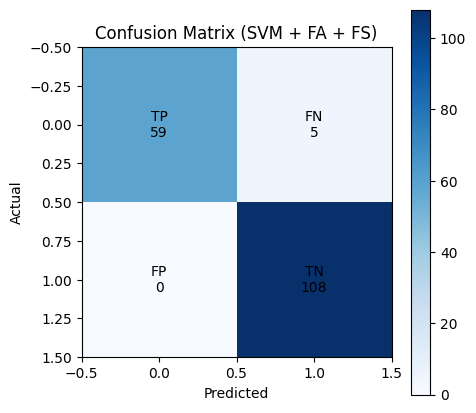

In [31]:
# PREDIKSI & EVALUASI (SVM + FA + FS)

y_pred_fs_fa3 = svm_predict(
    X_test_fs,
    w_fs_fa3,
    b_fs_fa3
)

acc_fs_fa3, pre_fs_fa3, rec_fs_fa3, f1_fs_fa3, tp_fs_fa3, tn_fs_fa3, fp_fs_fa3, fn_fs_fa3 = evaluate_model(
    y_test,
    y_pred_fs_fa3
)

print("\n===== SVM + FA + FS =====")

print(f"Accuracy : {acc_fs_fa3*100:.2f}%")
print(f"Precision: {pre_fs_fa3*100:.2f}%")
print(f"Recall   : {rec_fs_fa3*100:.2f}%")
print(f"F1 Score : {f1_fs_fa3*100:.2f}%")

print(f"TP:{tp_fs_fa3}, TN:{tn_fs_fa3}, FP:{fp_fs_fa3}, FN:{fn_fs_fa3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_fs_fa3, tn_fs_fa3,
    fp_fs_fa3, fn_fs_fa3,
    title="Confusion Matrix (SVM + FA + FS)"
)

AUC Score (SVM + FA + FS): 0.9990


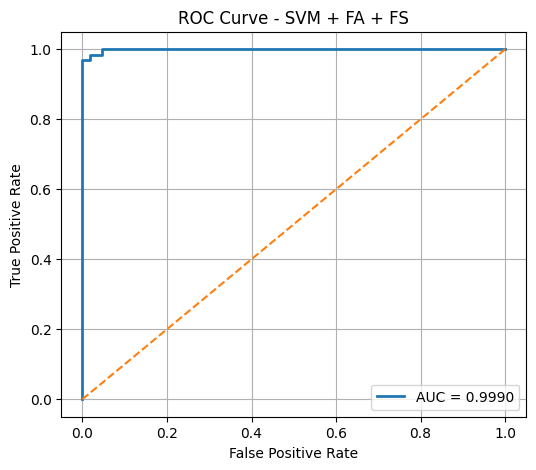

In [32]:
# ROC-AUC (SVM + FA + FS)

scores_fs_fa3 = svm_decision_function(
    X_test_fs,
    w_fs_fa3,
    b_fs_fa3
)

auc_fs_fa3 = roc_auc_score(
    y_test,
    scores_fs_fa3
)

print(f"AUC Score (SVM + FA + FS): {auc_fs_fa3:.4f}")

fpr_fs_fa3, tpr_fs_fa3, _ = roc_curve(
    y_test,
    scores_fs_fa3
)

plt.figure(figsize=(6,5))

plt.plot(fpr_fs_fa3, tpr_fs_fa3,
        linewidth=2,
        label=f"AUC = {auc_fs_fa3:.4f}")

plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - SVM + FA + FS")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

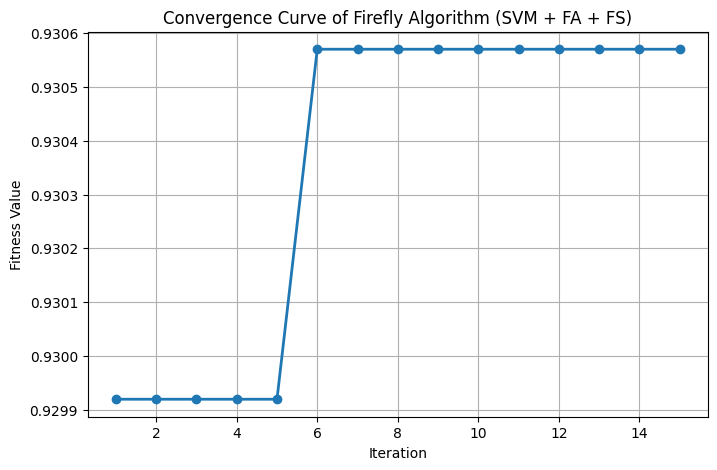

In [33]:
# CONVERGENCE CURVE (SVM + FA + FS)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(history_fs_fa3)+1),
        history_fs_fa3,
        marker='o',
        linewidth=2)
plt.title("Convergence Curve of Firefly Algorithm (SVM + FA + FS)")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")
plt.grid(True)
plt.show()

## 8. Evaluasi Akhir

In [34]:
# FUNCTION PLOT ROC CURVE

def plot_roc_curve(fpr, tpr,
                title="ROC Curve"):
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, linewidth=2)
    # garis random classifier
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.show()


===== BASELINE SVM =====
Accuracy : 93.60%
Precision: 100.00%
Recall   : 82.81%
F1 Score : 90.60%
AUC Score: 0.9986
TP:53, TN:108, FP:0, FN:11


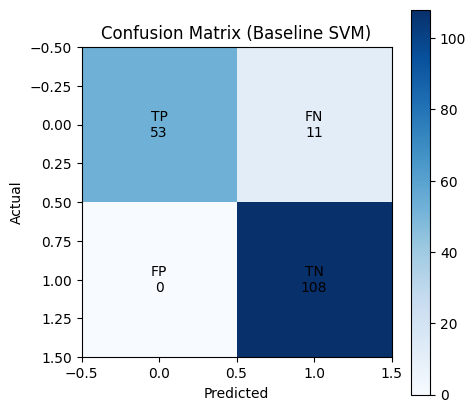

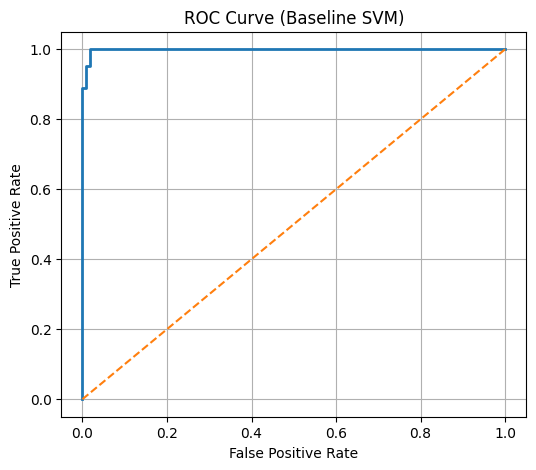

In [35]:
# BASELINE SVM

# PREDIKSI & EVALUASI
y_pred_svm3 = svm_predict(X_test, w_base3, b_base3)

acc_svm3, pre_svm3, rec_svm3, f1_svm3, tp_svm3, tn_svm3, fp_svm3, fn_svm3 = evaluate_model(
    y_test,
    y_pred_svm3
)

# ROC-AUC
scores_svm3 = svm_decision_function(
    X_test,
    w_base3,
    b_base3
)

auc_svm3 = roc_auc_score(
    y_test,
    scores_svm3
)

fpr_svm3, tpr_svm3, _ = roc_curve(
    y_test,
    scores_svm3
)

# HASIL
print("\n===== BASELINE SVM =====")

print(f"Accuracy : {acc_svm3*100:.2f}%")
print(f"Precision: {pre_svm3*100:.2f}%")
print(f"Recall   : {rec_svm3*100:.2f}%")
print(f"F1 Score : {f1_svm3*100:.2f}%")
print(f"AUC Score: {auc_svm3:.4f}")

print(f"TP:{tp_svm3}, TN:{tn_svm3}, FP:{fp_svm3}, FN:{fn_svm3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_svm3, tn_svm3,
    fp_svm3, fn_svm3,
    title="Confusion Matrix (Baseline SVM)"
)

# ROC CURVE
plot_roc_curve(
    fpr_svm3,
    tpr_svm3,
    title="ROC Curve (Baseline SVM)"
)


===== SVM + FEATURE SELECTION =====
Accuracy : 92.44%
Precision: 100.00%
Recall   : 79.69%
F1 Score : 88.70%
AUC Score: 0.9968
TP:51, TN:108, FP:0, FN:13


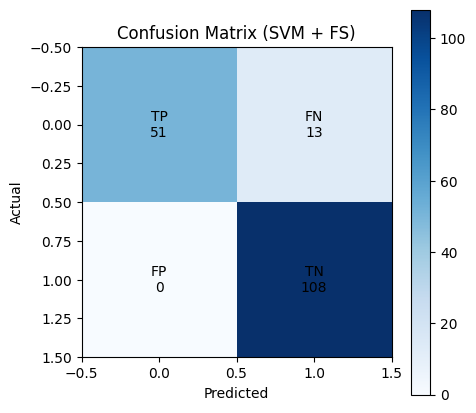

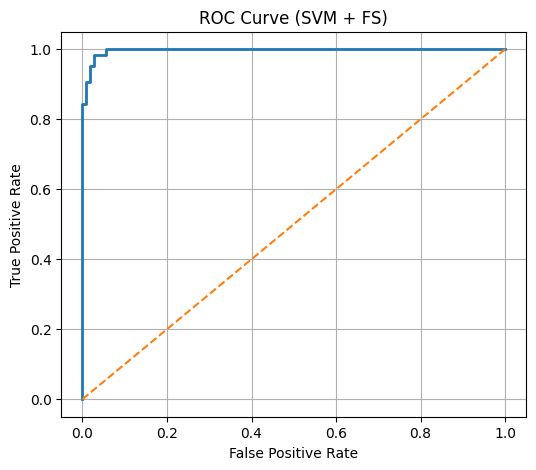

In [36]:
# SVM + FEATURE SELECTION

# PREDIKSI & EVALUASI
y_pred_fs3 = svm_predict(X_test_fs, w_fs3, b_fs3)

acc_fs3, pre_fs3, rec_fs3, f1_fs3, tp_fs3, tn_fs3, fp_fs3, fn_fs3 = evaluate_model(
    y_test,
    y_pred_fs3
)

# ROC-AUC
scores_fs3 = svm_decision_function(
    X_test_fs,
    w_fs3,
    b_fs3
)

auc_fs3 = roc_auc_score(
    y_test,
    scores_fs3
)

fpr_fs3, tpr_fs3, _ = roc_curve(
    y_test,
    scores_fs3
)

# HASIL
print("\n===== SVM + FEATURE SELECTION =====")

print(f"Accuracy : {acc_fs3*100:.2f}%")
print(f"Precision: {pre_fs3*100:.2f}%")
print(f"Recall   : {rec_fs3*100:.2f}%")
print(f"F1 Score : {f1_fs3*100:.2f}%")
print(f"AUC Score: {auc_fs3:.4f}")

print(f"TP:{tp_fs3}, TN:{tn_fs3}, FP:{fp_fs3}, FN:{fn_fs3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_fs3, tn_fs3,
    fp_fs3, fn_fs3,
    title="Confusion Matrix (SVM + FS)"
)

# ROC CURVE
plot_roc_curve(
    fpr_fs3,
    tpr_fs3,
    title="ROC Curve (SVM + FS)"
)


===== SVM + FIREFLY ALGORITHM =====
Accuracy : 97.09%
Precision: 98.36%
Recall   : 93.75%
F1 Score : 96.00%
AUC Score: 0.9955
TP:60, TN:107, FP:1, FN:4


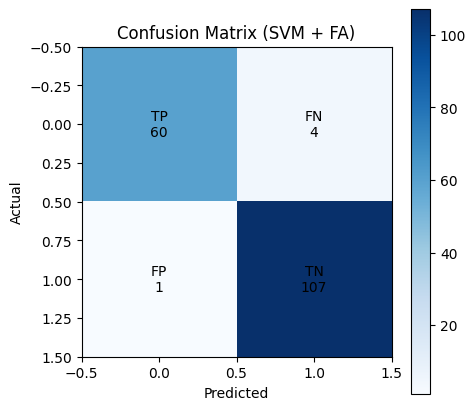

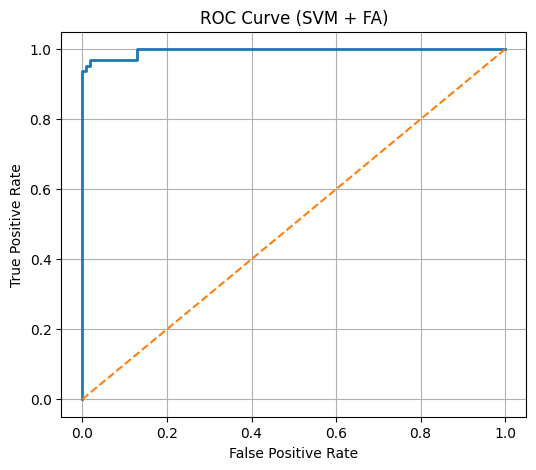

In [37]:
# SVM + FIREFLY ALGORITHM

# PREDIKSI & EVALUASI
y_pred_fa3 = svm_predict(X_test, w_fa3, b_fa3)

acc_fa3, pre_fa3, rec_fa3, f1_fa3, tp_fa3, tn_fa3, fp_fa3, fn_fa3 = evaluate_model(
    y_test,
    y_pred_fa3
)

# ROC-AUC
scores_fa3 = svm_decision_function(
    X_test,
    w_fa3,
    b_fa3
)

auc_fa3 = roc_auc_score(
    y_test,
    scores_fa3
)

fpr_fa3, tpr_fa3, _ = roc_curve(
    y_test,
    scores_fa3
)

# HASIL
print("\n===== SVM + FIREFLY ALGORITHM =====")

print(f"Accuracy : {acc_fa3*100:.2f}%")
print(f"Precision: {pre_fa3*100:.2f}%")
print(f"Recall   : {rec_fa3*100:.2f}%")
print(f"F1 Score : {f1_fa3*100:.2f}%")
print(f"AUC Score: {auc_fa3:.4f}")

print(f"TP:{tp_fa3}, TN:{tn_fa3}, FP:{fp_fa3}, FN:{fn_fa3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_fa3, tn_fa3,
    fp_fa3, fn_fa3,
    title="Confusion Matrix (SVM + FA)"
)

# ROC CURVE
plot_roc_curve(
    fpr_fa3,
    tpr_fa3,
    title="ROC Curve (SVM + FA)"
)


===== SVM + FIREFLY ALGORITHM + FEATURE SELECTION =====
Accuracy : 97.09%
Precision: 100.00%
Recall   : 92.19%
F1 Score : 95.93%
AUC Score: 0.9990
TP:59, TN:108, FP:0, FN:5


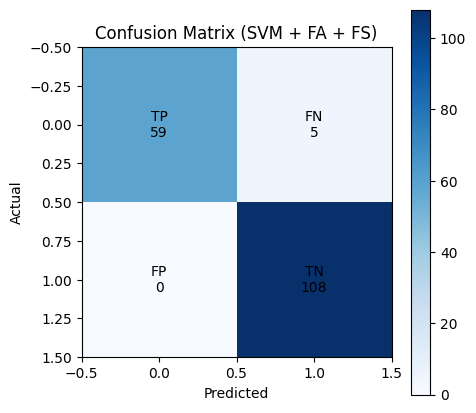

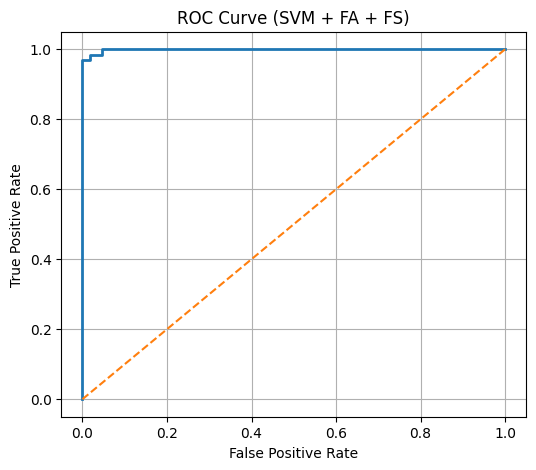

In [38]:
# SVM + FIREFLY ALGORITHM + FEATURE SELECTION

# PREDIKSI & EVALUASI
y_pred_fs_fa3 = svm_predict(
    X_test_fs,
    w_fs_fa3,
    b_fs_fa3
)

acc_fs_fa3, pre_fs_fa3, rec_fs_fa3, f1_fs_fa3, tp_fs_fa3, tn_fs_fa3, fp_fs_fa3, fn_fs_fa3 = evaluate_model(
    y_test,
    y_pred_fs_fa3
)

# ROC-AUC
scores_fs_fa3 = svm_decision_function(
    X_test_fs,
    w_fs_fa3,
    b_fs_fa3
)

auc_fs_fa3 = roc_auc_score(
    y_test,
    scores_fs_fa3
)

fpr_fs_fa3, tpr_fs_fa3, _ = roc_curve(
    y_test,
    scores_fs_fa3
)

# HASIL
print("\n===== SVM + FIREFLY ALGORITHM + FEATURE SELECTION =====")

print(f"Accuracy : {acc_fs_fa3*100:.2f}%")
print(f"Precision: {pre_fs_fa3*100:.2f}%")
print(f"Recall   : {rec_fs_fa3*100:.2f}%")
print(f"F1 Score : {f1_fs_fa3*100:.2f}%")
print(f"AUC Score: {auc_fs_fa3:.4f}")

print(f"TP:{tp_fs_fa3}, TN:{tn_fs_fa3}, FP:{fp_fs_fa3}, FN:{fn_fs_fa3}")

# CONFUSION MATRIX
plot_confusion_matrix(
    tp_fs_fa3, tn_fs_fa3,
    fp_fs_fa3, fn_fs_fa3,
    title="Confusion Matrix (SVM + FA + FS)"
)

# ROC CURVE
plot_roc_curve(
    fpr_fs_fa3,
    tpr_fs_fa3,
    title="ROC Curve (SVM + FA + FS)"
)

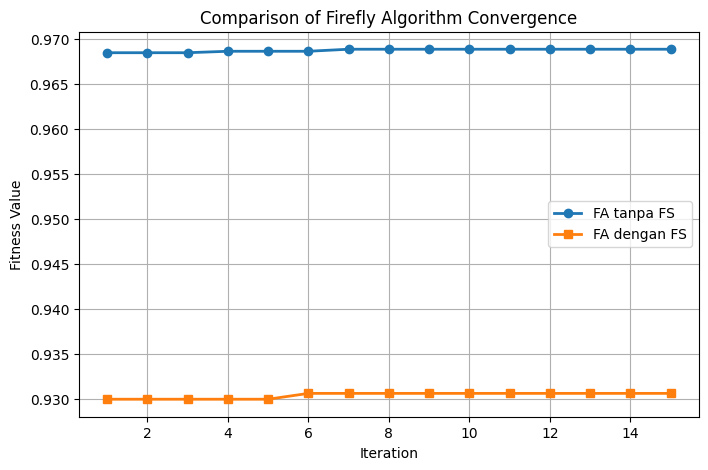

In [39]:
# PERBANDINGAN KONVERGENSI FA

plt.figure(figsize=(8,5))

plt.plot(range(1, len(history_fa3)+1),
        history_fa3,
        marker='o',
        linewidth=2,
        label='FA tanpa FS')

plt.plot(range(1, len(history_fs_fa3)+1),
        history_fs_fa3,
        marker='s',
        linewidth=2,
        label='FA dengan FS')

plt.title("Comparison of Firefly Algorithm Convergence")
plt.xlabel("Iteration")
plt.ylabel("Fitness Value")
plt.legend()
plt.grid(True)
plt.show()

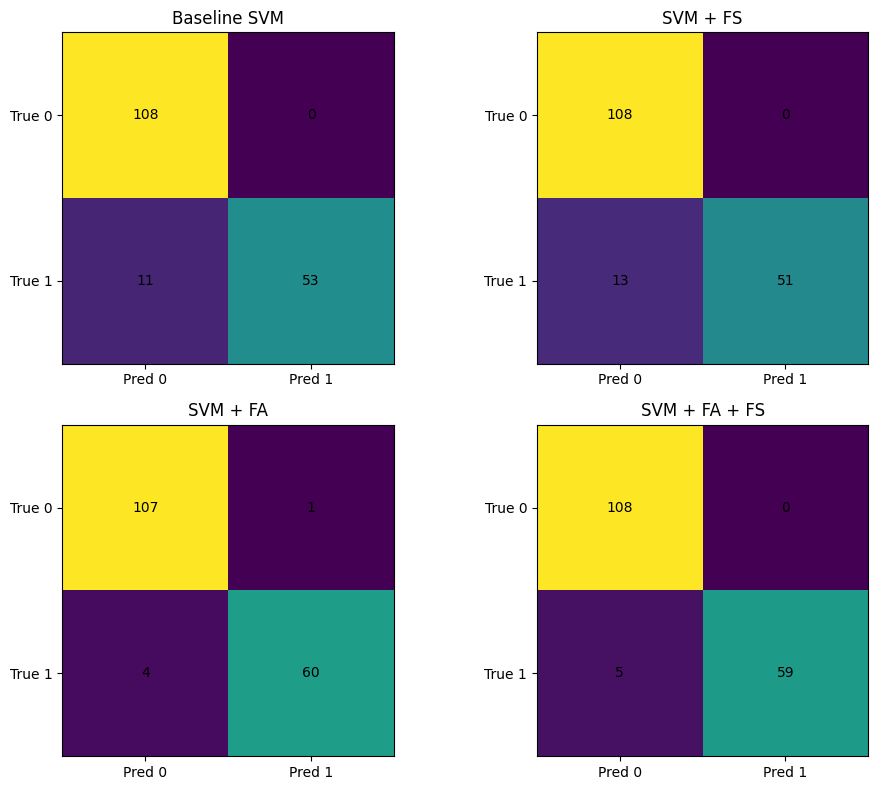

In [40]:
# PERBANDINGAN CONFUSION MATRIX

fig, axes = plt.subplots(2, 2, figsize=(10,8))

models_cm = [
    ("Baseline SVM", tp_svm3, tn_svm3, fp_svm3, fn_svm3),
    ("SVM + FS", tp_fs3, tn_fs3, fp_fs3, fn_fs3),
    ("SVM + FA", tp_fa3, tn_fa3, fp_fa3, fn_fa3),
    ("SVM + FA + FS", tp_fs_fa3, tn_fs_fa3, fp_fs_fa3, fn_fs_fa3)
]

for ax_cm, (title_cm, tp_cm, tn_cm, fp_cm, fn_cm) in zip(axes.ravel(), models_cm):

    cm_matrix = np.array([[tn_cm, fp_cm], [fn_cm, tp_cm]])

    ax_cm.imshow(cm_matrix)

    ax_cm.set_title(title_cm)

    ax_cm.set_xticks([0,1])
    ax_cm.set_yticks([0,1])

    ax_cm.set_xticklabels(["Pred 0", "Pred 1"])
    ax_cm.set_yticklabels(["True 0", "True 1"])

    for i_cm in range(2):
        for j_cm in range(2):

            ax_cm.text(j_cm, i_cm,
                    cm_matrix[i_cm, j_cm],
                    ha='center',
                    va='center')
plt.tight_layout()
plt.show()

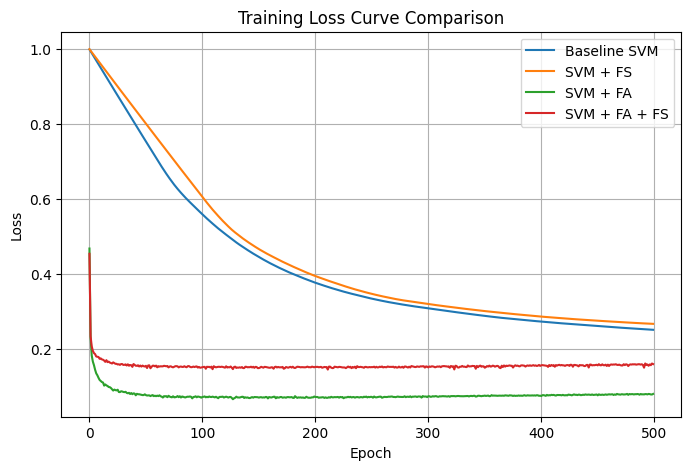

In [41]:
# PERBANDINGAN LOSS CURVE

plt.figure(figsize=(8,5))
plt.plot(losses_base3, label='Baseline SVM')
plt.plot(losses_fs3, label='SVM + FS')
plt.plot(losses_fa3, label='SVM + FA')
plt.plot(losses_fs_fa3, label='SVM + FA + FS')
plt.title("Training Loss Curve Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

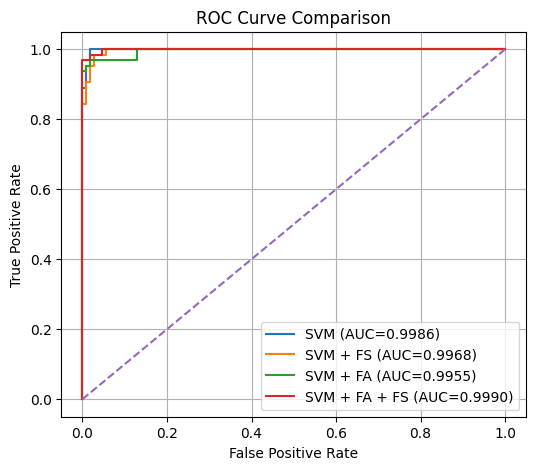

In [42]:
# PERBANDINGAN ROC CURVE

plt.figure(figsize=(6,5))
plt.plot(fpr_svm3, tpr_svm3,
        label=f"SVM (AUC={auc_svm3:.4f})")
plt.plot(fpr_fs3, tpr_fs3,
        label=f"SVM + FS (AUC={auc_fs3:.4f})")
plt.plot(fpr_fa3, tpr_fa3,
        label=f"SVM + FA (AUC={auc_fa3:.4f})")
plt.plot(fpr_fs_fa3, tpr_fs_fa3,
        label=f"SVM + FA + FS (AUC={auc_fs_fa3:.4f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
# PERBANDINGAN MODEL

print("\n===== PERBANDINGAN MODEL =====")

print(f"{'Model':<20}{'Acc (%)':<12}{'Prec (%)':<12}{'Recall (%)':<12}{'F1 (%)':<12}{'AUC':<10}")
print(f"{'Baseline SVM':<20}{acc_svm3*100:<12.2f}{pre_svm3*100:<12.2f}{rec_svm3*100:<12.2f}{f1_svm3*100:<12.2f}{auc_svm3:<10.4f}")
print(f"{'SVM + FS':<20}{acc_fs3*100:<12.2f}{pre_fs3*100:<12.2f}{rec_fs3*100:<12.2f}{f1_fs3*100:<12.2f}{auc_fs3:<10.4f}")
print(f"{'SVM + FA':<20}{acc_fa3*100:<12.2f}{pre_fa3*100:<12.2f}{rec_fa3*100:<12.2f}{f1_fa3*100:<12.2f}{auc_fa3:<10.4f}")
print(f"{'SVM + FA + FS':<20}{acc_fs_fa3*100:<12.2f}{pre_fs_fa3*100:<12.2f}{rec_fs_fa3*100:<12.2f}{f1_fs_fa3*100:<12.2f}{auc_fs_fa3:<10.4f}")


===== PERBANDINGAN MODEL =====
Model               Acc (%)     Prec (%)    Recall (%)  F1 (%)      AUC       
Baseline SVM        93.60       100.00      82.81       90.60       0.9986    
SVM + FS            92.44       100.00      79.69       88.70       0.9968    
SVM + FA            97.09       98.36       93.75       96.00       0.9955    
SVM + FA + FS       97.09       100.00      92.19       95.93       0.9990    


In [44]:
# CROSS VALIDATION SEMUA MODEL

def cross_validate_all_models(
    X, y, selected_idx,
    lr_base=0.001,
    lam_base=0.001,
    C_base=0.1,
    best_lr_fa=None,
    best_lambda_fa=None,
    best_C_fa=None,
    best_lr_fs_fa=None,
    best_lambda_fs_fa=None,
    best_C_fs_fa=None,
    k=5
):

    results_cv = []

    for fold_cv, (X_tr_cv, X_val_cv, y_tr_cv, y_val_cv) in enumerate(
        kfold_split_stratified(X, y, k), start=1
    ):

        X_tr_fs_cv = X_tr_cv[:, selected_idx]
        X_val_fs_cv = X_val_cv[:, selected_idx]

        # BASELINE SVM
        w_svm_cv, b_svm_cv, _ = svm_train(
            X_tr_cv, y_tr_cv,
            lr=lr_base, C=C_base,
            lambda_param=lam_base,
            epochs=200,
            early_stop=True
        )

        y_pred_svm_cv = svm_predict(
            X_val_cv,
            w_svm_cv,
            b_svm_cv
        )

        _, _, _, f1_svm_cv, *_ = evaluate_model(
            y_val_cv,
            y_pred_svm_cv
        )

        # SVM + FS
        w_fs_cv, b_fs_cv, _ = svm_train(
            X_tr_fs_cv, y_tr_cv,
            lr=lr_base, C=C_base,
            lambda_param=lam_base,
            epochs=200,
            early_stop=True
        )

        y_pred_fs_cv = svm_predict(
            X_val_fs_cv,
            w_fs_cv,
            b_fs_cv
        )

        _, _, _, f1_fs_cv, *_ = evaluate_model(
            y_val_cv,
            y_pred_fs_cv
        )

        # SVM + FA
        w_fa_cv, b_fa_cv, _ = svm_train(
            X_tr_cv, y_tr_cv,
            lr=best_lr_fa,
            C=best_C_fa,
            lambda_param=best_lambda_fa,
            epochs=200,
            early_stop=True
        )

        y_pred_fa_cv = svm_predict(
            X_val_cv,
            w_fa_cv,
            b_fa_cv
        )

        _, _, _, f1_fa_cv, *_ = evaluate_model(
            y_val_cv,
            y_pred_fa_cv
        )

        # SVM + FA + FS
        w_fs_fa_cv, b_fs_fa_cv, _ = svm_train(
            X_tr_fs_cv, y_tr_cv,
            lr=best_lr_fs_fa,
            C=best_C_fs_fa,
            lambda_param=best_lambda_fs_fa,
            epochs=200,
            early_stop=True
        )

        y_pred_fs_fa_cv = svm_predict(
            X_val_fs_cv,
            w_fs_fa_cv,
            b_fs_fa_cv
        )

        _, _, _, f1_fs_fa_cv, *_ = evaluate_model(
            y_val_cv,
            y_pred_fs_fa_cv
        )

        results_cv.append([
            fold_cv,
            f1_svm_cv,
            f1_fs_cv,
            f1_fa_cv,
            f1_fs_fa_cv
        ])

    return results_cv

In [45]:
# CROSS VALIDATION

cv_results1 = cross_validate_all_models(
    X_train,
    y_train,
    selected_idx_fs,

    lr_base=0.001,
    lam_base=0.001,
    C_base=0.1,

    best_lr_fa=best_lr_fa3,
    best_lambda_fa=best_lambda_fa3,
    best_C_fa=best_C_fa3,

    best_lr_fs_fa=best_lr_fs_fa3,
    best_lambda_fs_fa=best_lambda_fs_fa3,
    best_C_fs_fa=best_C_fs_fa3
)

===== TRAINING SVM =====
Epoch 1/200 | Loss: 0.998197
Epoch 10/200 | Loss: 0.962425
Epoch 20/200 | Loss: 0.922804
Epoch 30/200 | Loss: 0.883314
Epoch 40/200 | Loss: 0.843955
Epoch 50/200 | Loss: 0.804724
Epoch 60/200 | Loss: 0.765627
Epoch 70/200 | Loss: 0.726652
Epoch 80/200 | Loss: 0.687831
Epoch 90/200 | Loss: 0.651798
Epoch 100/200 | Loss: 0.621509
Epoch 110/200 | Loss: 0.595682
Epoch 120/200 | Loss: 0.571881
Epoch 130/200 | Loss: 0.548911
Epoch 140/200 | Loss: 0.527827
Epoch 150/200 | Loss: 0.508318
Epoch 160/200 | Loss: 0.490055
Epoch 170/200 | Loss: 0.472949
Epoch 180/200 | Loss: 0.458045
Epoch 190/200 | Loss: 0.444620
Epoch 200/200 | Loss: 0.431985
===== TRAINING SVM =====
Epoch 1/200 | Loss: 0.998514
Epoch 10/200 | Loss: 0.969829
Epoch 20/200 | Loss: 0.938032
Epoch 30/200 | Loss: 0.906312
Epoch 40/200 | Loss: 0.874667
Epoch 50/200 | Loss: 0.843100
Epoch 60/200 | Loss: 0.811610
Epoch 70/200 | Loss: 0.780184
Epoch 80/200 | Loss: 0.748842
Epoch 90/200 | Loss: 0.717565
Epoch 100/2

In [46]:
# HASIL CROSS VALIDATION

print("\n===== CROSS VALIDATION SEMUA MODEL =====")

print(f"{'Fold':<8}{'SVM':<12}{'SVM+FS':<12}{'SVM+FA':<12}{'SVM+FA+FS':<14}")

for row_cv in cv_results1:

    print(f"{row_cv[0]:<8}"
        f"{row_cv[1]*100:<12.2f}"
        f"{row_cv[2]*100:<12.2f}"
        f"{row_cv[3]*100:<12.2f}"
        f"{row_cv[4]*100:<14.2f}")

# RATA-RATA & STD
cv_array1 = np.array(cv_results1)[:,1:]

mean_vals1 = np.mean(cv_array1, axis=0)

std_vals1 = np.std(cv_array1, axis=0)

print("\n===== RATA-RATA & STD DEV =====")

print(f"{'Mean':<8}"
    f"{mean_vals1[0]*100:<12.2f}"
    f"{mean_vals1[1]*100:<12.2f}"
    f"{mean_vals1[2]*100:<12.2f}"
    f"{mean_vals1[3]*100:<14.2f}")

print(f"{'Std':<8}"
    f"{std_vals1[0]*100:<12.2f}"
    f"{std_vals1[1]*100:<12.2f}"
    f"{std_vals1[2]*100:<12.2f}"
    f"{std_vals1[3]*100:<14.2f}")


===== CROSS VALIDATION SEMUA MODEL =====
Fold    SVM         SVM+FS      SVM+FA      SVM+FA+FS     
1       82.35       69.57       96.67       93.33         
2       69.57       60.47       91.80       91.80         
3       82.35       77.55       91.53       91.23         
4       79.17       76.60       100.00      96.43         
5       76.60       73.91       92.86       88.89         

===== RATA-RATA & STD DEV =====
Mean    78.01       71.62       94.57       92.34         
Std     4.74        6.23        3.28        2.50          


In [47]:
# FRIEDMAN TEST

from scipy.stats import friedmanchisquare

svm_scores1 = cv_array1[:,0]

fs_scores1 = cv_array1[:,1]

fa_scores1 = cv_array1[:,2]

fs_fa_scores1 = cv_array1[:,3]

stat1, p_value1 = friedmanchisquare(
    svm_scores1,
    fs_scores1,
    fa_scores1,
    fs_fa_scores1
)

print("\n===== FRIEDMAN TEST =====")

print(f"Statistic : {stat1:.4f}")

print(f"P-Value   : {p_value1:.6f}")

alpha1 = 0.05

if p_value1 < alpha1:

    print("\nTerdapat perbedaan signifikan antar model.")

else:

    print("\nTidak terdapat perbedaan signifikan antar model.")


===== FRIEDMAN TEST =====
Statistic : 14.7551
P-Value   : 0.002038

Terdapat perbedaan signifikan antar model.
